Dataset Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [2]:
np.random.seed(42)
# True underlying function (no noise)
def true_function(x):
    return np.sin(1.5 * np.pi * x)

# Generate noisy dataset
n_samples = 200
X = np.sort(np.random.rand(n_samples))          # 200 random x values in [0,1]
y = true_function(X) + np.random.normal(0, 0.25, n_samples)  # add Gaussian noise
X = X.reshape(-1, 1)                            # reshape to 2D for sklearn

# Train/Test split (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# X_grid is used for smooth plotting of predictions
X_grid = np.linspace(0, 1, 500).reshape(-1, 1)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")

Training samples : 140
Test samples     : 60


PART-A Decision Tree Regressor

In [ ]:
# A1 Train a fully grown tree compute MSE
full_tree = DecisionTreeRegressor(max_depth=None, random_state=42)
full_tree.fit(X_train, y_train)

# Predictions
train_pred = full_tree.predict(X_train)
test_pred  = full_tree.predict(X_test)

train_mse_full = mean_squared_error(y_train, train_pred)
test_mse_full  = mean_squared_error(y_test,  test_pred)

print("Fully Grown Decision Tree (max_depth=None)")
print(f" Train MSE : {train_mse_full:.4f}")
print(f" Test  MSE : {test_mse_full:.4f}")

Fully Grown Decision Tree (max_depth=None)
 Train MSE : 0.0000
 Test  MSE : 0.1205


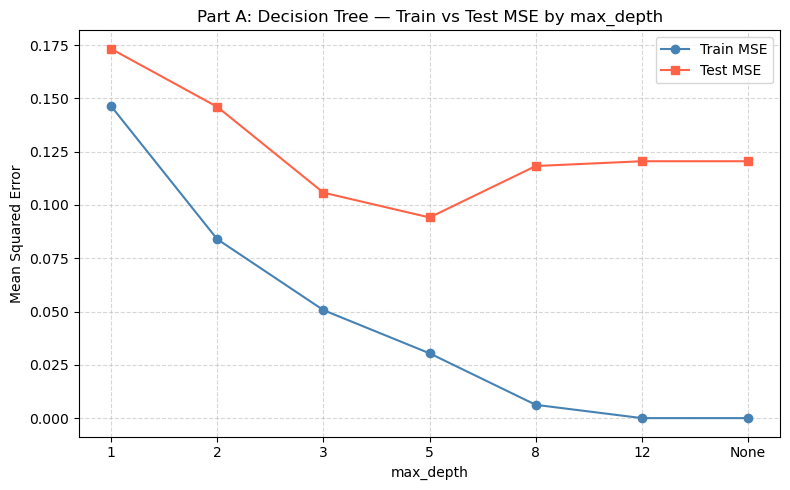

In [4]:
# A2 Loop over different max_depth values and record MSE ──
depths = [1, 2, 3, 5, 8, 12, None]   # depths to evaluate
train_mses = []
test_mses  = []

for d in depths:
    dt = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_mses.append(mean_squared_error(y_train, dt.predict(X_train)))
    test_mses.append(mean_squared_error(y_test,  dt.predict(X_test)))

# Use numeric labels for x-axis (replace None with 'None')
depth_labels = [str(d) for d in depths]

# ─Plot Train MSE vs Test MSE ──
plt.figure(figsize=(8, 5))
plt.plot(depth_labels, train_mses, marker='o', label='Train MSE', color='steelblue')
plt.plot(depth_labels, test_mses,  marker='s', label='Test MSE',  color='tomato')
plt.xlabel('max_depth')
plt.ylabel('Mean Squared Error')
plt.title('Part A: Decision Tree — Train vs Test MSE by max_depth')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



PART-B Random Forest Regressor

In [5]:
# ─ B1: Train Random Forest with 200 trees and compare with single full tree ──

rf = RandomForestRegressor(n_estimators=200, max_depth=None, random_state=42)
rf.fit(X_train, y_train)

rf_train_mse = mean_squared_error(y_train, rf.predict(X_train))
rf_test_mse  = mean_squared_error(y_test,  rf.predict(X_test))

print("Random Forest (n_estimators=200, max_depth=None)")
print(f"  Train MSE : {rf_train_mse:.4f}")
print(f"  Test  MSE : {rf_test_mse:.4f}")

print("\nComparison with Single Fully-Grown Tree:")
print(f"  Single Tree  — Train MSE: {train_mse_full:.4f}  |  Test MSE: {test_mse_full:.4f}")
print(f"  Random Forest — Train MSE: {rf_train_mse:.4f}  |  Test MSE: {rf_test_mse:.4f}")

Random Forest (n_estimators=200, max_depth=None)
  Train MSE : 0.0105
  Test  MSE : 0.1012

Comparison with Single Fully-Grown Tree:
  Single Tree  — Train MSE: 0.0000  |  Test MSE: 0.1205
  Random Forest — Train MSE: 0.0105  |  Test MSE: 0.1012


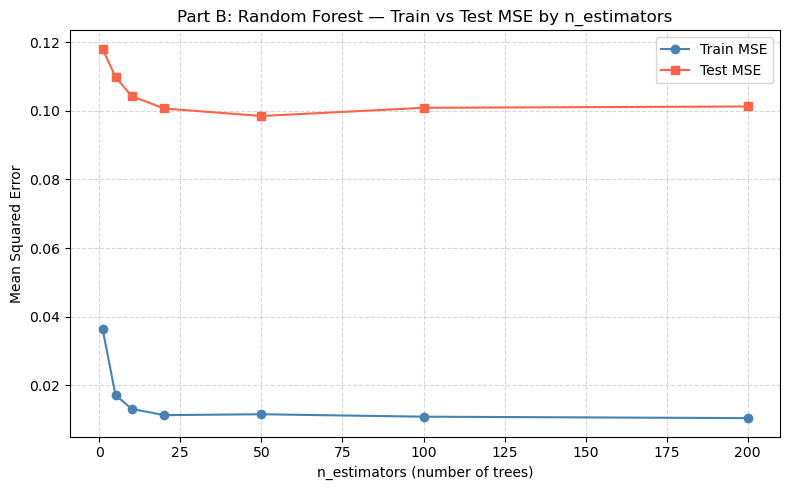

In [6]:
# ─B2: Vary n_estimators and plot Train/Test MSE ──

n_trees_list = [1, 5, 10, 20, 50, 100, 200]
rf_train_mses = []
rf_test_mses  = []

for n in n_trees_list:
    rf_n = RandomForestRegressor(n_estimators=n, max_depth=None, random_state=42)
    rf_n.fit(X_train, y_train)
    rf_train_mses.append(mean_squared_error(y_train, rf_n.predict(X_train)))
    rf_test_mses.append(mean_squared_error(y_test,  rf_n.predict(X_test)))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(n_trees_list, rf_train_mses, marker='o', label='Train MSE', color='steelblue')
plt.plot(n_trees_list, rf_test_mses,  marker='s', label='Test MSE',  color='tomato')
plt.xlabel('n_estimators (number of trees)')
plt.ylabel('Mean Squared Error')
plt.title('Part B: Random Forest — Train vs Test MSE by n_estimators')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



PART - C

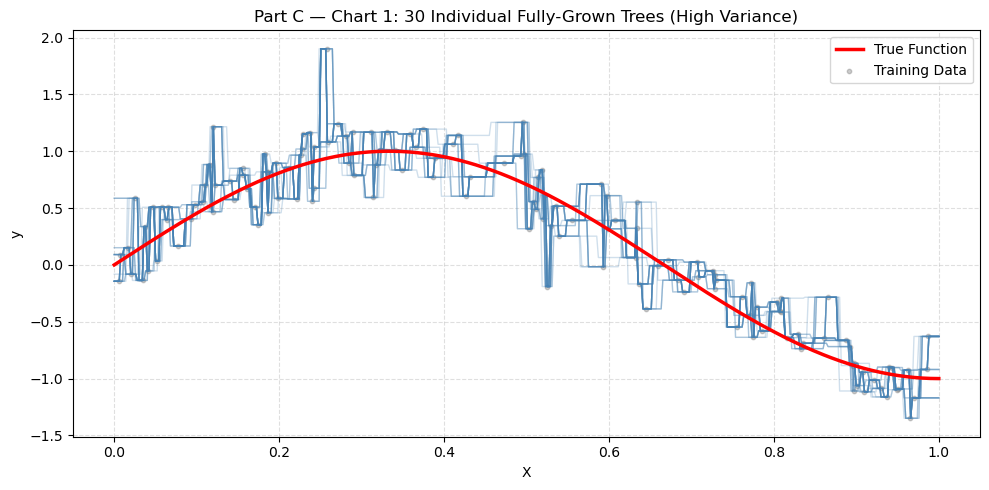

In [7]:
# ── C1: Train 30 individual fully-grown trees on different bootstrap samples ──
#        and overlay all 30 predictions on one chart

n_bootstrap_trees = 30
n_train = X_train.shape[0]

# Store all 30 predictions on the grid
all_preds = np.zeros((n_bootstrap_trees, X_grid.shape[0]))

plt.figure(figsize=(10, 5))

for i in range(n_bootstrap_trees):
    # Create a bootstrap sample (random sample WITH replacement)
    indices = np.random.choice(n_train, size=n_train, replace=True)
    X_boot = X_train[indices]
    y_boot = y_train[indices]

    # Train a fully-grown tree on the bootstrap sample
    dt_boot = DecisionTreeRegressor(max_depth=None, random_state=i)
    dt_boot.fit(X_boot, y_boot)

    # Predict on the grid and store
    pred_i = dt_boot.predict(X_grid)
    all_preds[i] = pred_i

    # Plot each tree's prediction with low opacity so spread is visible
    plt.plot(X_grid, pred_i, color='steelblue', alpha=0.25, linewidth=1)

# Plot the true function on top
plt.plot(X_grid, true_function(X_grid), color='red', linewidth=2.5,
         label='True Function', zorder=5)

plt.scatter(X_train, y_train, s=10, color='gray', alpha=0.4, label='Training Data')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Part C — Chart 1: 30 Individual Fully-Grown Trees (High Variance)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

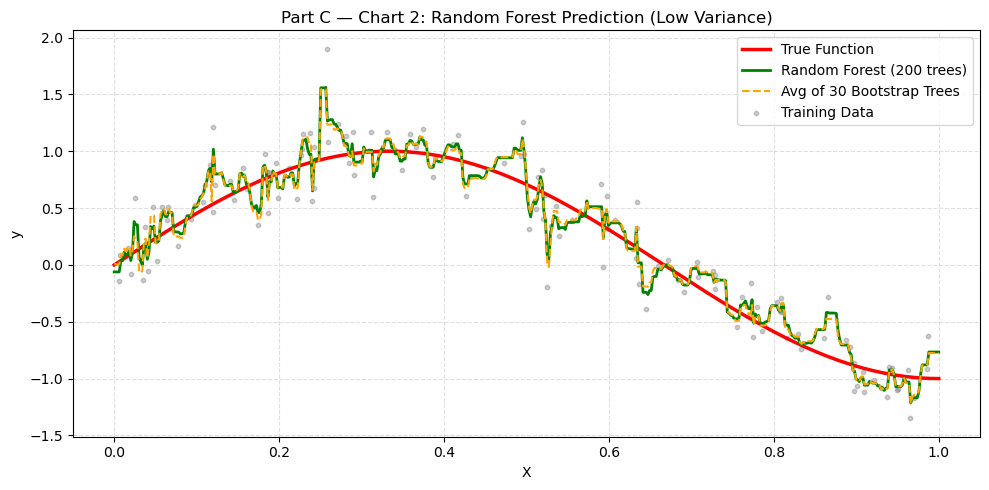

Average variance of 30 individual tree predictions : 0.0256
Variance of Random Forest prediction               : 0.0000  (single model)


In [8]:
# ── C2: Plot prediction of a single Random Forest (200 trees) ──

rf_200 = RandomForestRegressor(n_estimators=200, max_depth=None, random_state=42)
rf_200.fit(X_train, y_train)

rf_grid_pred = rf_200.predict(X_grid)       # smooth prediction over grid
mean_of_30   = all_preds.mean(axis=0)       # average of 30 individual trees

plt.figure(figsize=(10, 5))

# Plot true function
plt.plot(X_grid, true_function(X_grid), color='red', linewidth=2.5,
         label='True Function')

# Plot RF prediction
plt.plot(X_grid, rf_grid_pred, color='green', linewidth=2,
         label='Random Forest (200 trees)')

# Plot average of 30 bootstrap trees for reference
plt.plot(X_grid, mean_of_30, color='orange', linewidth=1.5,
         linestyle='--', label='Avg of 30 Bootstrap Trees')

plt.scatter(X_train, y_train, s=10, color='gray', alpha=0.4, label='Training Data')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Part C — Chart 2: Random Forest Prediction (Low Variance)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Compute variance across 30 tree predictions at each grid point
variance_30_trees = all_preds.var(axis=0).mean()
variance_rf       = 0.0   # single deterministic predictor has 0 variance

print(f"Average variance of 30 individual tree predictions : {variance_30_trees:.4f}")
print(f"Variance of Random Forest prediction               : {variance_rf:.4f}  (single model)")